# EDA dataset

In [1]:
import pandas as pd
df_schiz=pd.read_csv(r"C:\Users\laiar\Desktop\Classe IDIBAPS\data_sintetica\Data-sintetica\Data-sintetica\src\csv merged\cohort_schizophrenia_sociodemografica.csv")
df_study=pd.read_csv(r"C:\Users\laiar\Desktop\Classe IDIBAPS\data_sintetica\Data-sintetica\Data-sintetica\src\csv merged\cohort_estudi_sociodemografica.csv")

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Sociodemographic description

### Schizophrenia Cohort

In [ ]:
print(f"Shape: {df_schiz.shape}")
print(f"\nColumns: {df_schiz.columns.tolist()}")
print(f"\nMissing values:\n{df_schiz.isna().sum()}")
print(f"\nBasic stats:\n{df_schiz.describe()}")

Shape: (9969, 15)

Columns: ['id', 'idCas', 'SEXE1', 'SEXE2', 'EDAT_rang', 'NACIONALITAT1', 'NACIONALITAT2', 'DATAMORT', 'NIVSOC', 'VAL', 'BMI_first', 'BMI_last', 'never_smoker', 'current_smoker', 'ex_smoker']

Missing values:
id                   0
idCas                0
SEXE1                0
SEXE2                0
EDAT_rang            0
NACIONALITAT1        0
NACIONALITAT2        0
DATAMORT             0
NIVSOC               0
VAL               2381
BMI_first         8754
BMI_last          8754
never_smoker      2381
current_smoker    2381
ex_smoker         2381
dtype: int64

Basic stats:
                  id         idCas        SEXE1          VAL    BMI_first  \
count    9969.000000  9.969000e+03  9969.000000  7588.000000  1215.000000   
mean   271981.335340  9.502044e+07     0.357107     0.677122    30.600519   
std    119993.038623  4.147817e+06     0.479171     0.478749     6.509935   
min        34.000000  6.943461e+07     0.000000     0.000000     4.670000   
25%    182716.00

C:\Users\laiar\AppData\Local\Temp\ipykernel_500\2014916918.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_schiz, x="SEXE2", ax=axes[0,0], palette="pastel")
C:\Users\laiar\AppData\Local\Temp\ipykernel_500\2014916918.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_schiz, x="EDAT_rang", order=age_order, ax=axes[0,1], palette="pastel")
C:\Users\laiar\AppData\Local\Temp\ipykernel_500\2014916918.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_schiz, x="NIVSOC", order=nivsoc_order, ax=axes[1,0], palette=

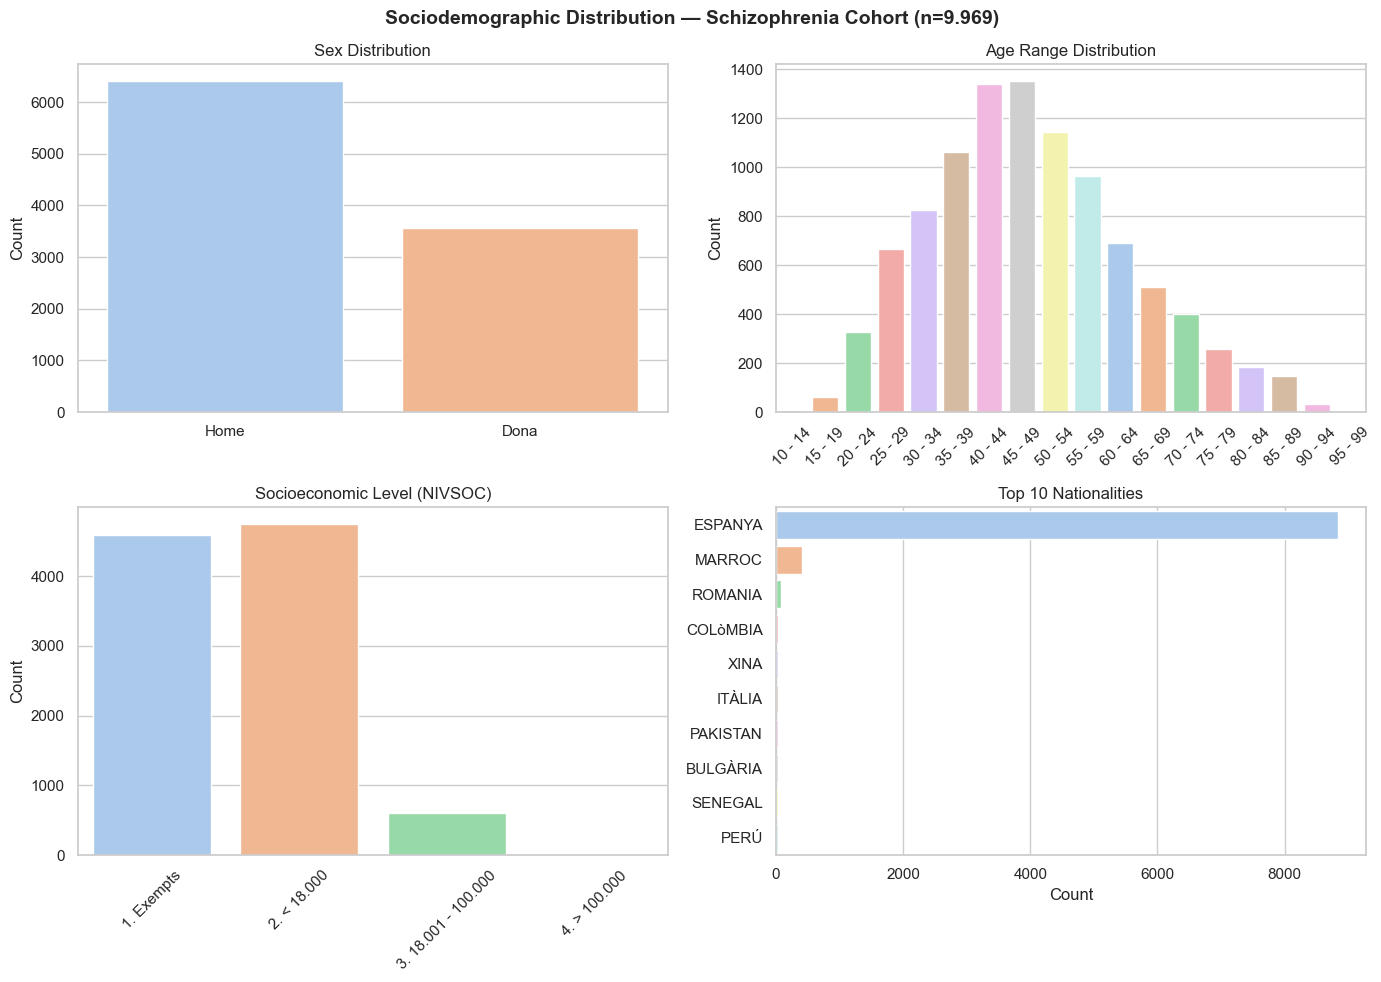

In [23]:
# Set seaborn style globally
sns.set_theme(style="whitegrid", palette="pastel")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Sociodemographic Distribution — Schizophrenia Cohort (n=9.969)", fontsize=14, fontweight="bold")

# Sex
sns.countplot(data=df_schiz, x="SEXE2", ax=axes[0,0], palette="pastel")
axes[0,0].set_title("Sex Distribution")
axes[0,0].set_xlabel("")
axes[0,0].set_ylabel("Count")

# Age range
age_order = sorted(df_schiz["EDAT_rang"].dropna().unique())
sns.countplot(data=df_schiz, x="EDAT_rang", order=age_order, ax=axes[0,1], palette="pastel")
axes[0,1].set_title("Age Range Distribution")
axes[0,1].set_xlabel("")
axes[0,1].set_ylabel("Count")
axes[0,1].tick_params(axis="x", rotation=45)

# Socioeconomic level
nivsoc_order = sorted(df_schiz["NIVSOC"].dropna().unique())
sns.countplot(data=df_schiz, x="NIVSOC", order=nivsoc_order, ax=axes[1,0], palette="pastel")
axes[1,0].set_title("Socioeconomic Level (NIVSOC)")
axes[1,0].set_xlabel("")
axes[1,0].set_ylabel("Count")
axes[1,0].tick_params(axis="x", rotation=45)

# Nationality (top 10)
top_nat = df_schiz["NACIONALITAT2"].value_counts().head(10).index
sns.countplot(data=df_schiz[df_schiz["NACIONALITAT2"].isin(top_nat)],
              y="NACIONALITAT2", order=top_nat, ax=axes[1,1], palette="pastel")
axes[1,1].set_title("Top 10 Nationalities")
axes[1,1].set_xlabel("Count")
axes[1,1].set_ylabel("")

plt.tight_layout()
plt.savefig("sociodemographic_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

#### Mortality rate

In [6]:
# Convert DATAMORT to datetime
df_schiz['DATAMORT'] = pd.to_datetime(df_schiz['DATAMORT'], errors='coerce')

# Mortality flag
df_schiz['died'] = df_schiz['DATAMORT'].notna()

total = len(df_schiz)
died = df_schiz['died'].sum()
alive = total - died

print(f"Total patients:  {total}")
print(f"Deceased:        {died} ({died/total*100:.1f}%)")
print(f"Alive:           {alive} ({alive/total*100:.1f}%)")

Total patients:  9969
Deceased:        684 (6.9%)
Alive:           9285 (93.1%)


C:\Users\laiar\AppData\Local\Temp\ipykernel_500\3520429857.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_schiz['DATAMORT'] = pd.to_datetime(df_schiz['DATAMORT'], errors='coerce')


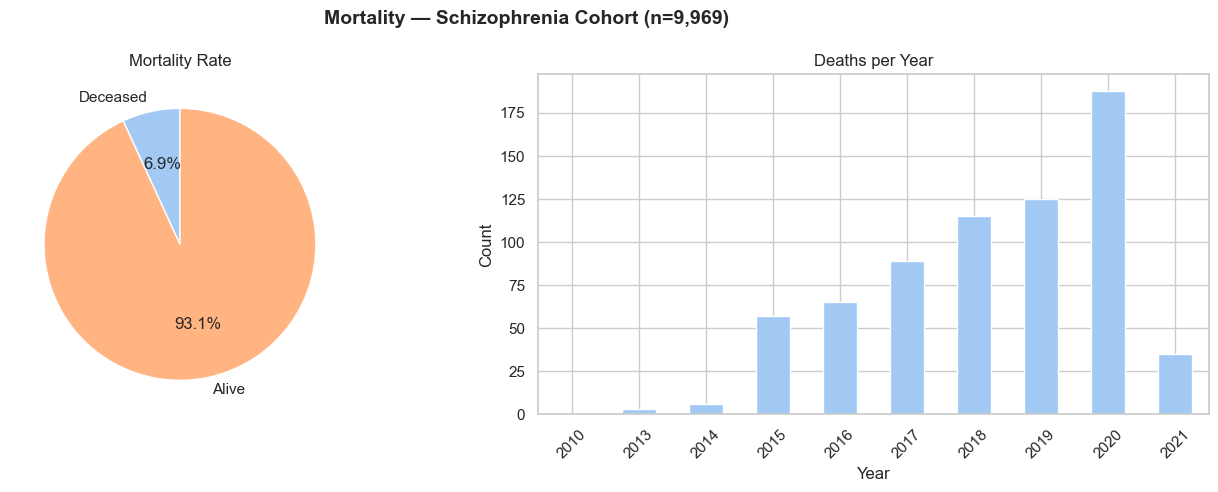

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Mortality — Schizophrenia Cohort (n=9,969)', fontsize=14, fontweight='bold')

# Pie chart
axes[0].pie([died, alive], labels=['Deceased', 'Alive'],
            autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=90)
axes[0].set_title('Mortality Rate')

# Deaths over time
df_schiz[df_schiz['died']]['DATAMORT'].dt.year.value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=sns.color_palette('pastel')[0])
axes[1].set_title('Deaths per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('mortality.png', dpi=150, bbox_inches='tight')
plt.show()

### Study cohort

In [ ]:
df_study=pd.read_csv(r"C:\Users\laiar\Desktop\Classe IDIBAPS\data_sintetica\Data-sintetica\Data-sintetica\src\csv merged\cohort_estudi_sociodemografica.csv")

In [14]:
print(f"Shape: {df_study.shape}")
print(f"\nColumns: {df_study.columns.tolist()}")
print(f"\nMissing values:\n{df_study.isna().sum()}")
print(f"\nBasic stats:\n{df_study.describe()}")

Shape: (473812, 15)

Columns: ['id', 'idCas', 'SEXE1', 'SEXE2', 'EDAT_rang', 'NACIONALITAT1', 'NACIONALITAT2', 'DATAMORT', 'NIVSOC', 'VAL', 'BMI_first', 'BMI_last', 'never_smoker', 'current_smoker', 'ex_smoker']

Missing values:
id                     0
idCas                  0
SEXE1                  0
SEXE2                  0
EDAT_rang              0
NACIONALITAT1          0
NACIONALITAT2          0
DATAMORT               0
NIVSOC                 0
VAL               182248
BMI_first         415997
BMI_last          415985
never_smoker      182248
current_smoker    182248
ex_smoker         182248
dtype: int64

Basic stats:
                 id         idCas          SEXE1            VAL     BMI_first  \
count  473812.00000  4.738120e+05  473812.000000  291564.000000  57815.000000   
mean   236906.50000  9.345487e+07       0.536358       0.490897     27.419097   
std    136777.88721  5.211937e+06       0.498677       0.508523      7.172557   
min         1.00000  6.717005e+07       0.000

In [32]:
age_order = sorted(df_study['EDAT_rang'].dropna().unique(), 
                   key=lambda x: int(x.strip().split(' - ')[0].strip()))

C:\Users\laiar\AppData\Local\Temp\ipykernel_500\3141416077.py:8: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.countplot(data=df_study, x="SEXE2", hue="SEXE2", legend=False, ax=axes[0,0], palette=custom2)
C:\Users\laiar\AppData\Local\Temp\ipykernel_500\3141416077.py:16: UserWarning: 
The palette list has fewer values (5) than needed (21) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=df_study, x="EDAT_rang", hue="EDAT_rang", order=age_order, legend=False, ax=axes[0,1], palette=custom2)
C:\Users\laiar\AppData\Local\Temp\ipykernel_500\3141416077.py:24: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.countplot(data=df_study, x="NIVSOC", hue="NIVSOC", order=nivsoc_order, legend=False, ax=axes[1,0], palette=custom2)
C:\Users\laiar\AppData\Local\Temp\ipykernel_500\3141416077.py:32: UserWarning: 
The palette list has fewer values (5) than needed (10) and w

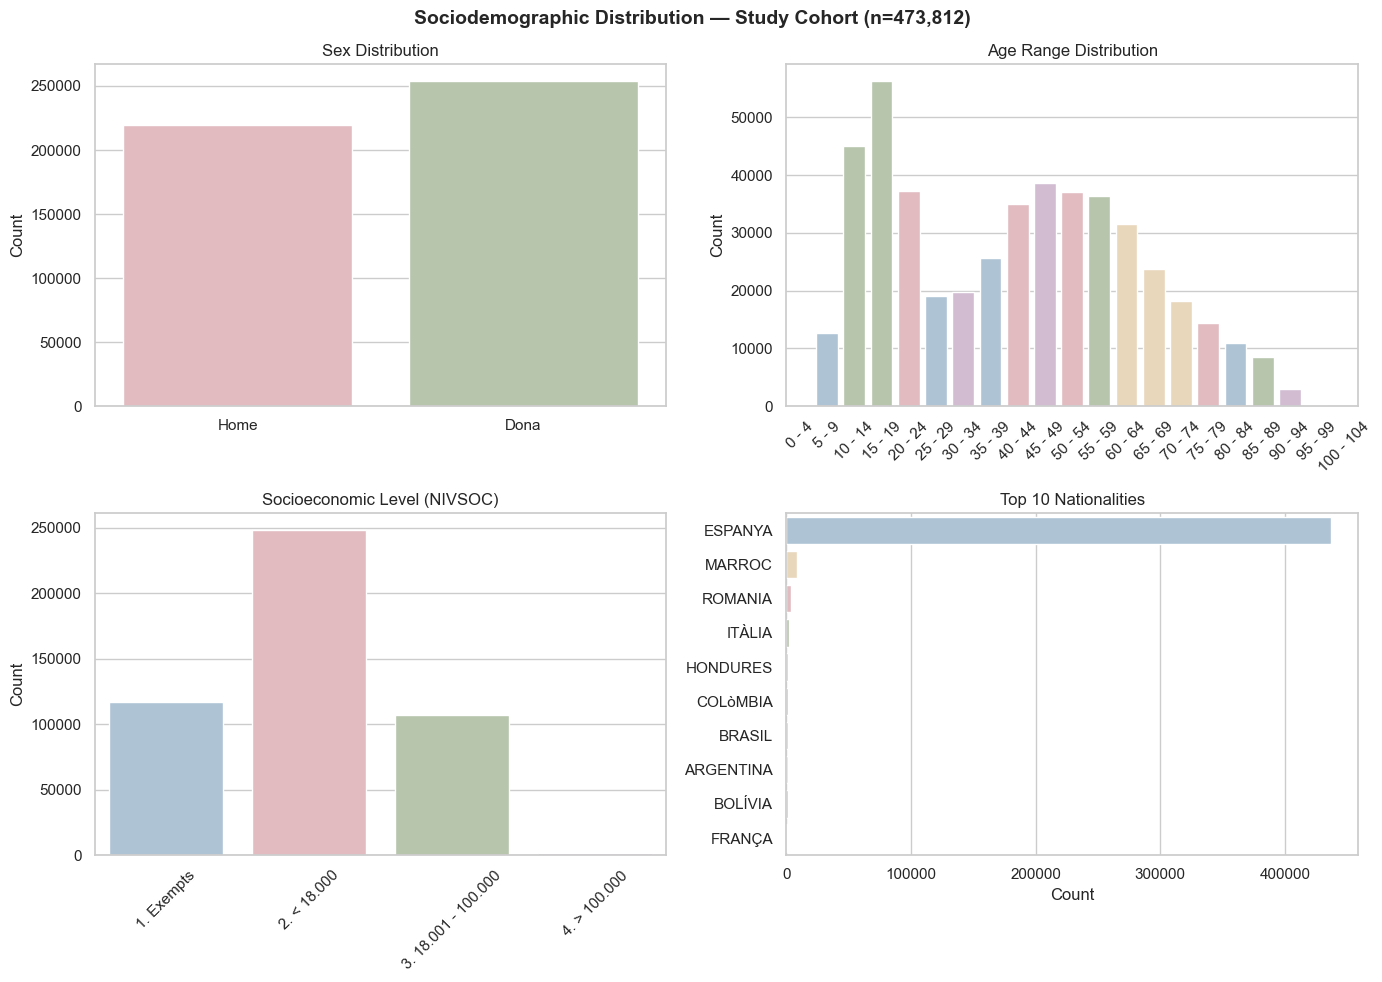

In [34]:
custom2 = ['#E8B4BC', '#B7C9A8', '#A8C5DA', '#D4B8D4', '#F0D9B5']
sns.set_theme(style="whitegrid", palette=custom2)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Sociodemographic Distribution — Study Cohort (n=473,812)", fontsize=14, fontweight="bold")

# Sex
sns.countplot(data=df_study, x="SEXE2", hue="SEXE2", legend=False, ax=axes[0,0], palette=custom2)
axes[0,0].set_title("Sex Distribution")
axes[0,0].set_xlabel("")
axes[0,0].set_ylabel("Count")

# Age range — fixed ordering
age_order = sorted(df_study["EDAT_rang"].dropna().unique(),
                   key=lambda x: int(x.strip().split(' - ')[0].strip()))
sns.countplot(data=df_study, x="EDAT_rang", hue="EDAT_rang", order=age_order, legend=False, ax=axes[0,1], palette=custom2)
axes[0,1].set_title("Age Range Distribution")
axes[0,1].set_xlabel("")
axes[0,1].set_ylabel("Count")
axes[0,1].tick_params(axis="x", rotation=45)

# Socioeconomic level
nivsoc_order = sorted(df_study["NIVSOC"].dropna().unique())
sns.countplot(data=df_study, x="NIVSOC", hue="NIVSOC", order=nivsoc_order, legend=False, ax=axes[1,0], palette=custom2)
axes[1,0].set_title("Socioeconomic Level (NIVSOC)")
axes[1,0].set_xlabel("")
axes[1,0].set_ylabel("Count")
axes[1,0].tick_params(axis="x", rotation=45)

# Nationality (top 10)
top_nat = df_study["NACIONALITAT2"].value_counts().head(10).index
sns.countplot(data=df_study[df_study["NACIONALITAT2"].isin(top_nat)],
              y="NACIONALITAT2", hue="NACIONALITAT2", order=top_nat, legend=False,
              ax=axes[1,1], palette=custom2)
axes[1,1].set_title("Top 10 Nationalities")
axes[1,1].set_xlabel("Count")
axes[1,1].set_ylabel("")

plt.tight_layout()
plt.savefig("study_sociodemographic_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### Mortality rate

In [24]:
# Convert DATAMORT to datetime
df_study['DATAMORT'] = pd.to_datetime(df_study['DATAMORT'], errors='coerce')

# Mortality flag
df_study['died'] = df_study['DATAMORT'].notna()

total = len(df_study)
died = df_study['died'].sum()
alive = total - died

print(f"Total patients:  {total}")
print(f"Deceased:        {died} ({died/total*100:.1f}%)")
print(f"Alive:           {alive} ({alive/total*100:.1f}%)")

Total patients:  473812
Deceased:        19917 (4.2%)
Alive:           453895 (95.8%)


C:\Users\laiar\AppData\Local\Temp\ipykernel_500\838573038.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_study['DATAMORT'] = pd.to_datetime(df_study['DATAMORT'], errors='coerce')


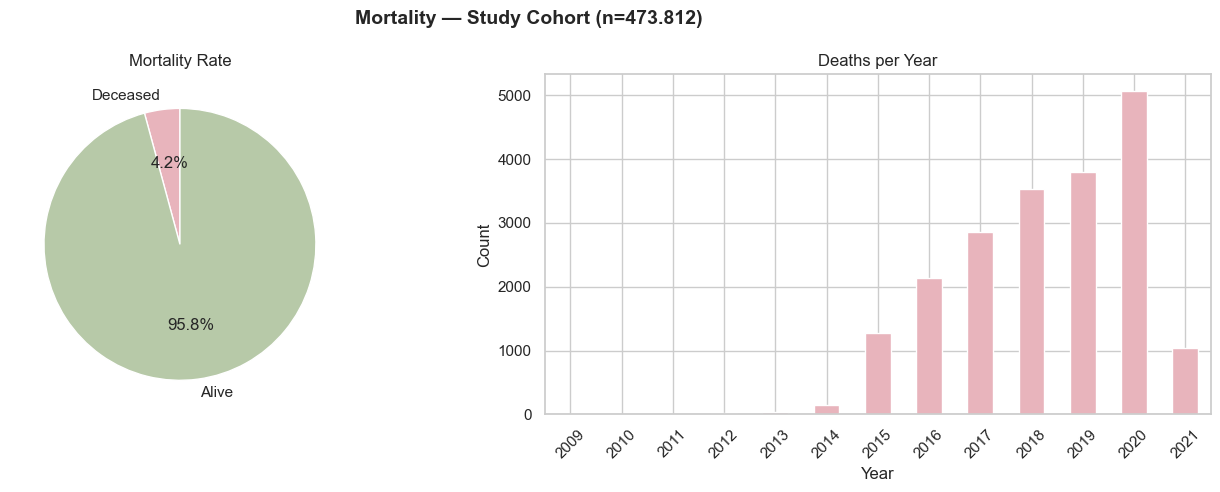

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Mortality — Study Cohort (n=473.812)', fontsize=14, fontweight='bold')

# Pie chart
axes[0].pie([died, alive], labels=['Deceased', 'Alive'],
            autopct='%1.1f%%', colors=sns.color_palette(custom2), startangle=90)
axes[0].set_title('Mortality Rate')

# Deaths over time
df_study[df_study['died']]['DATAMORT'].dt.year.value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=sns.color_palette(custom2)[0])
axes[1].set_title('Deaths per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('mortality.png', dpi=150, bbox_inches='tight')
plt.show()

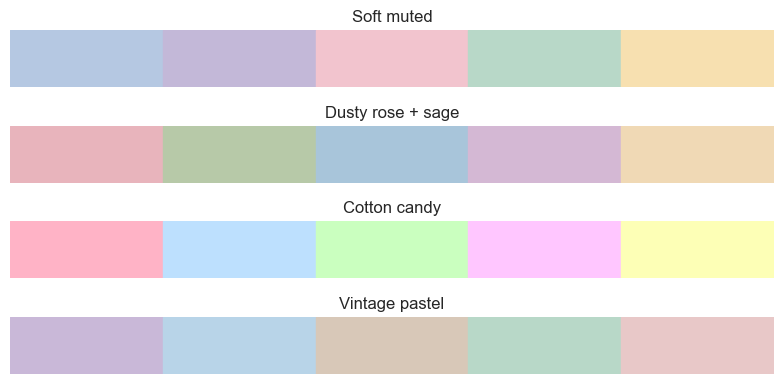

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

palettes = {
    'Soft muted': ['#B5C8E2', '#C3B8D8', '#F2C4CE', '#B8D8C8', '#F7E0B0'],
    'Dusty rose + sage': ['#E8B4BC', '#B7C9A8', '#A8C5DA', '#D4B8D4', '#F0D9B5'],
    'Cotton candy': ['#FFB3C6', '#BDE0FE', '#CAFFBF', '#FFC6FF', '#FDFFB6'],
    'Vintage pastel': ['#C9B8D8', '#B8D4E8', '#D8C8B8', '#B8D8C8', '#E8C8C8'],
}

fig, axes = plt.subplots(len(palettes), 1, figsize=(8, 4))
for ax, (name, pal) in zip(axes, palettes.items()):
    colors = sns.color_palette(pal)
    for i, color in enumerate(colors):
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color))
    ax.set_xlim(0, len(colors))
    ax.set_ylim(0, 1)
    ax.set_title(name)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Smoking status

### Schizophrenia and study cohort

C:\Users\laiar\AppData\Local\Temp\ipykernel_12724\3526226087.py:11: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.countplot(data=val_study.to_frame(), x="VAL", hue="VAL", legend=False,


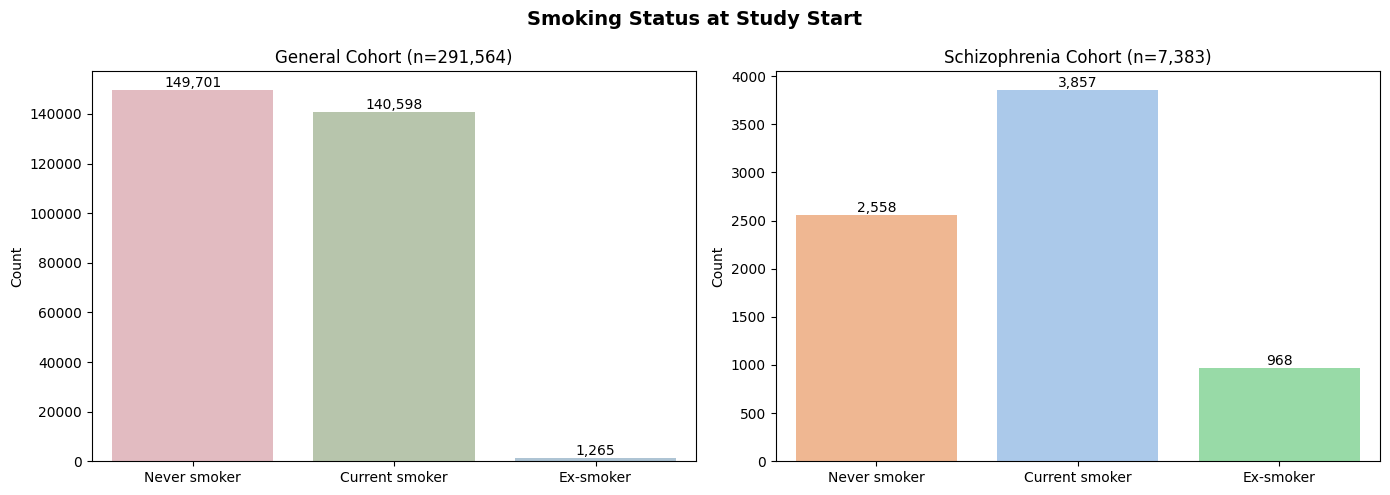

General Cohort:
VAL
Never smoker      51.3
Current smoker    48.2
Ex-smoker          0.4
Name: proportion, dtype: float64

Schizophrenia Cohort (at study start):
VAL_inici
Current smoker    52.2
Never smoker      34.6
Ex-smoker         13.1
Name: proportion, dtype: float64


In [6]:
custom2 = ['#E8B4BC', '#B7C9A8', '#A8C5DA', '#D4B8D4', '#F0D9B5']

# Just run the plot you already have replacing df_schiz["VAL"] with df_schiz["VAL_inici"]
val_labels = {0.0: "Never smoker", 1.0: "Current smoker", 2.0: "Ex-smoker"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Smoking Status at Study Start", fontsize=14, fontweight="bold")

# General cohort - uses existing VAL
val_study = df_study["VAL"].dropna().map(val_labels)
sns.countplot(data=val_study.to_frame(), x="VAL", hue="VAL", legend=False,
              order=val_labels.values(), ax=axes[0], palette=custom2)
axes[0].set_title(f"General Cohort (n={df_study['VAL'].notna().sum():,})")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom')

# Schizophrenia cohort - uses VAL_inici
val_schiz = df_schiz["VAL_inici"].dropna().map(val_labels)
sns.countplot(data=val_schiz.to_frame(), x="VAL_inici", hue="VAL_inici", legend=False,
              order=val_labels.values(), ax=axes[1], palette="pastel")
axes[1].set_title(f"Schizophrenia Cohort (n={df_schiz['VAL_inici'].notna().sum():,})")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom')

plt.tight_layout()
plt.savefig("smoking_status_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("General Cohort:")
print(df_study["VAL"].dropna().map(val_labels).value_counts(normalize=True).mul(100).round(1))
print("\nSchizophrenia Cohort (at study start):")
print(df_schiz["VAL_inici"].dropna().map(val_labels).value_counts(normalize=True).mul(100).round(1))

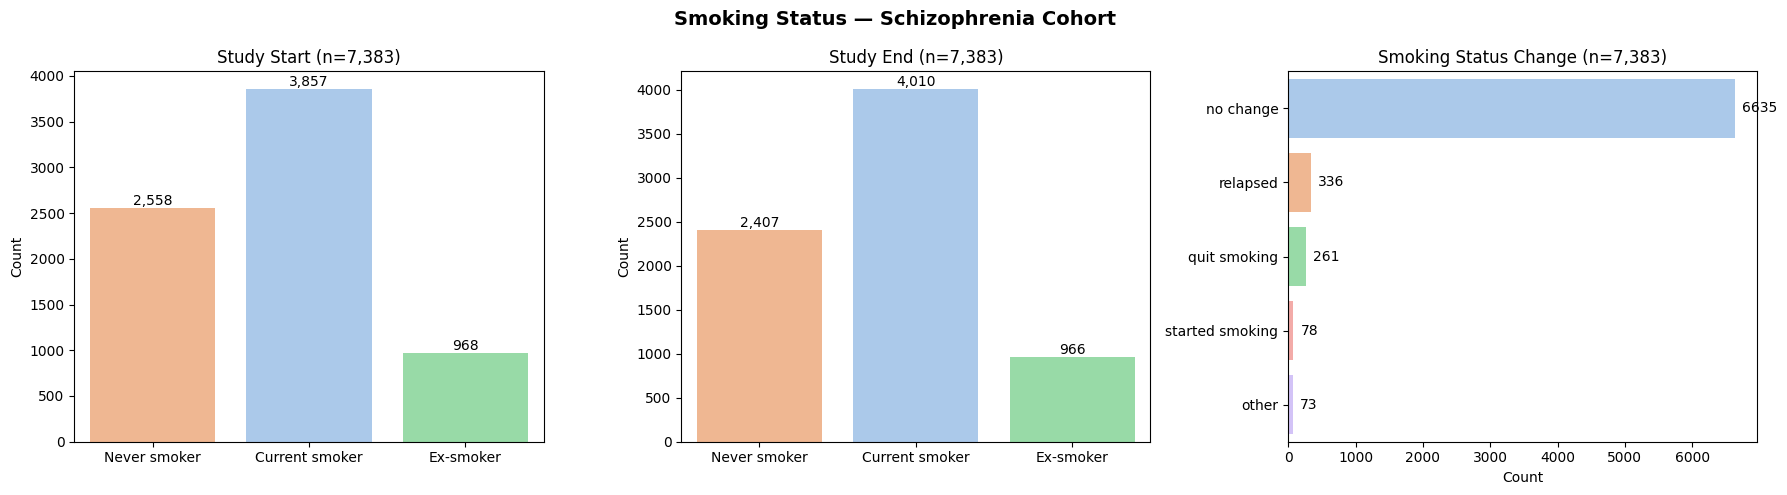

Study Start:
VAL_inici
Current smoker    52.2
Never smoker      34.6
Ex-smoker         13.1
Name: proportion, dtype: float64

Study End:
VAL_final
Current smoker    54.3
Never smoker      32.6
Ex-smoker         13.1
Name: proportion, dtype: float64

Change:
VAL_change
no change          6635
relapsed            336
quit smoking        261
started smoking      78
other                73
Name: count, dtype: int64


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Smoking Status — Schizophrenia Cohort", fontsize=14, fontweight="bold")

val_labels = {0.0: "Never smoker", 1.0: "Current smoker", 2.0: "Ex-smoker"}

# VAL at study start
val_inici = df_schiz["VAL_inici"].dropna().map(val_labels)
sns.countplot(data=val_inici.to_frame(), x="VAL_inici", hue="VAL_inici", legend=False,
              order=val_labels.values(), ax=axes[0], palette="pastel")
axes[0].set_title(f"Study Start (n={df_schiz['VAL_inici'].notna().sum():,})")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom')

# VAL at study end
val_final = df_schiz["VAL_final"].dropna().map(val_labels)
sns.countplot(data=val_final.to_frame(), x="VAL_final", hue="VAL_final", legend=False,
              order=val_labels.values(), ax=axes[1], palette="pastel")
axes[1].set_title(f"Study End (n={df_schiz['VAL_final'].notna().sum():,})")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom')

# VAL change
val_change_order = df_schiz["VAL_change"].value_counts().index
sns.countplot(data=df_schiz, y="VAL_change", hue="VAL_change", order=val_change_order,
              legend=False, ax=axes[2], palette="pastel")
axes[2].set_title(f"Smoking Status Change (n={df_schiz['VAL_change'].notna().sum():,})")
axes[2].set_xlabel("Count")
axes[2].set_ylabel("")
for p in axes[2].patches:
    axes[2].annotate(f'{int(p.get_width())}',
                     (p.get_width(), p.get_y() + p.get_height()/2.),
                     ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.savefig("smoking_status_schiz.png", dpi=150, bbox_inches="tight")
plt.show()

print("Study Start:")
print(df_schiz["VAL_inici"].dropna().map(val_labels).value_counts(normalize=True).mul(100).round(1))
print("\nStudy End:")
print(df_schiz["VAL_final"].dropna().map(val_labels).value_counts(normalize=True).mul(100).round(1))
print("\nChange:")
print(df_schiz["VAL_change"].value_counts())

In [43]:
# NAN values
total_schiz = len(df_schiz)
missing_smoking_schiz = df_schiz["VAL"].isna().sum()

print(f"Total schizophrenia patients:        {total_schiz}")
print(f"Missing smoking record:              {missing_smoking_schiz} ({missing_smoking_schiz/total_schiz*100:.1f}%)")
print(f"With smoking record:                 {total_schiz - missing_smoking_schiz} ({(total_schiz - missing_smoking_schiz)/total_schiz*100:.1f}%)")

print("---------------------")
total_study = len(df_study)
missing_smoking_study = df_study["VAL"].isna().sum()

print(f"Total study patients:                {total_study}")
print(f"Missing smoking record:              {missing_smoking_study} ({missing_smoking_study/total_study*100:.1f}%)")
print(f"With smoking record:                 {total_study - missing_smoking_study} ({(total_study - missing_smoking_study)/total_study*100:.1f}%)")

Total schizophrenia patients:        9969
Missing smoking record:              2381 (23.9%)
With smoking record:                 7588 (76.1%)
---------------------
Total study patients:                473812
Missing smoking record:              182248 (38.5%)
With smoking record:                 291564 (61.5%)


## BMI

### Schizophrenia

C:\Users\laiar\AppData\Local\Temp\ipykernel_500\1876881038.py:31: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.boxplot(data=df_schiz, x="SEXE2", y="BMI_first", hue="SEXE2", legend=False,
C:\Users\laiar\AppData\Local\Temp\ipykernel_500\1876881038.py:43: UserWarning: 
The palette list has fewer values (10) than needed (18) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=bmi_age, x="EDAT_rang", y="BMI_mean", hue="EDAT_rang", legend=False,


BMI coverage: 1215 patients (12.2%)

BMI first:  mean=30.60, std=6.51
BMI last:   mean=30.60, std=6.47
BMI change: mean=-0.00, std=1.37


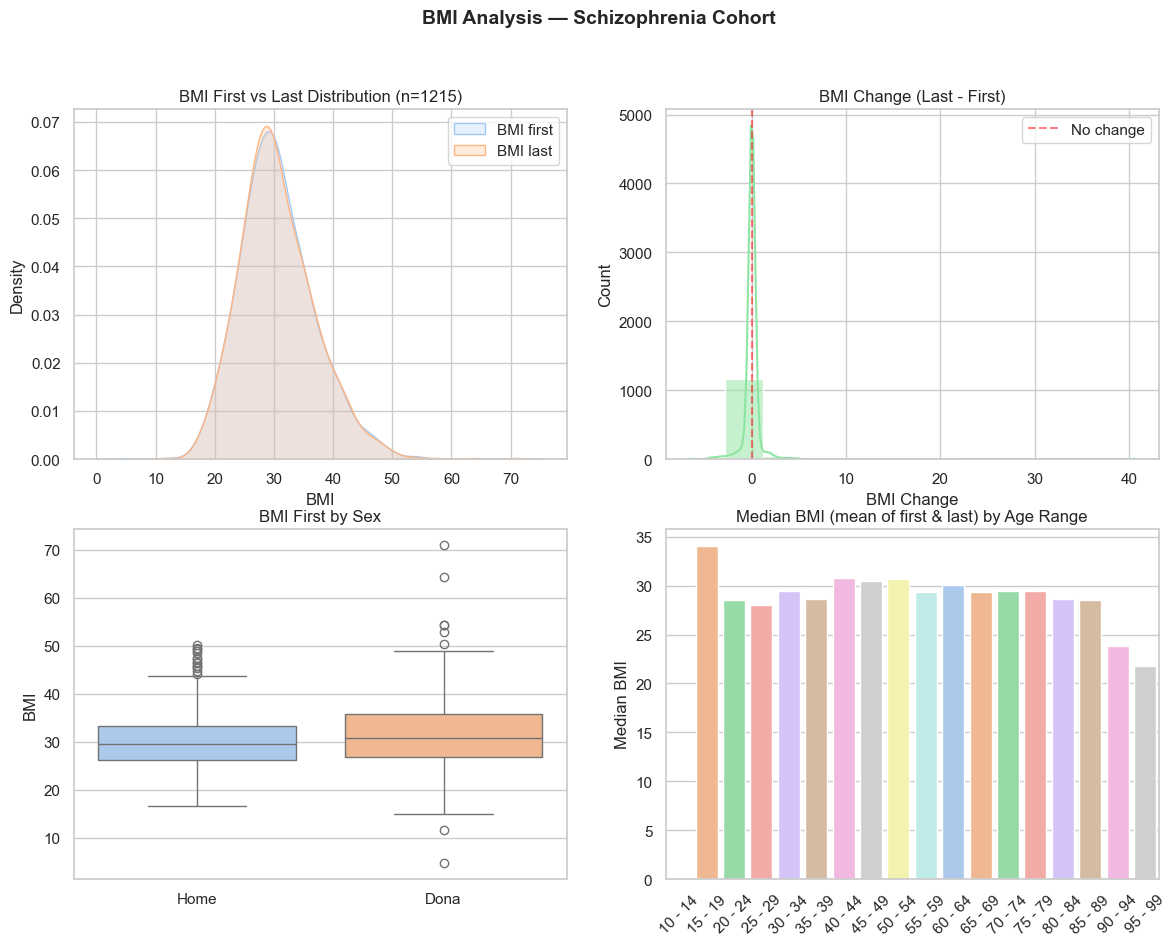

In [46]:
# Add BMI change column
df_schiz["BMI_change"] = df_schiz["BMI_last"] - df_schiz["BMI_first"]
cols = list(df_schiz.columns)
bmi_last_idx = cols.index("BMI_last")
cols.remove("BMI_change")
cols.insert(bmi_last_idx + 1, "BMI_change")
df_schiz = df_schiz[cols]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("BMI Analysis — Schizophrenia Cohort", fontsize=14, fontweight="bold")

pastel = sns.color_palette("pastel")

# BMI first vs last distribution
sns.kdeplot(data=df_schiz, x="BMI_first", ax=axes[0,0], label="BMI first", color=pastel[0], fill=True)
sns.kdeplot(data=df_schiz, x="BMI_last", ax=axes[0,0], label="BMI last", color=pastel[1], fill=True)
axes[0,0].set_title(f"BMI First vs Last Distribution (n={df_schiz['BMI_first'].notna().sum()})")
axes[0,0].set_xlabel("BMI")
axes[0,0].set_ylabel("Density")
axes[0,0].legend()

# BMI change
sns.histplot(data=df_schiz, x="BMI_change", ax=axes[0,1], color=pastel[2], kde=True)
axes[0,1].set_title("BMI Change (Last - First)")
axes[0,1].set_xlabel("BMI Change")
axes[0,1].set_ylabel("Count")
axes[0,1].axvline(0, color='red', linestyle='--', alpha=0.5, label='No change')
axes[0,1].legend()

# BMI by sex
sns.boxplot(data=df_schiz, x="SEXE2", y="BMI_first", hue="SEXE2", legend=False,
            ax=axes[1,0], palette=pastel)
axes[1,0].set_title("BMI First by Sex")
axes[1,0].set_xlabel("")
axes[1,0].set_ylabel("BMI")

# Mean of BMI first and last
df_schiz["BMI_mean"] = (df_schiz["BMI_first"] + df_schiz["BMI_last"]) / 2

# BMI mean by age range
bmi_age = df_schiz.groupby("EDAT_rang")["BMI_mean"].median().reset_index()
bmi_age = bmi_age.sort_values("EDAT_rang", key=lambda x: x.str.strip().str.split(' - ').str[0].astype(int))
sns.barplot(data=bmi_age, x="EDAT_rang", y="BMI_mean", hue="EDAT_rang", legend=False,
            ax=axes[1,1], palette=pastel)
axes[1,1].set_title("Median BMI (mean of first & last) by Age Range")
axes[1,1].set_xlabel("")
axes[1,1].set_ylabel("Median BMI")
axes[1,1].tick_params(axis="x", rotation=45)

# Summary stats
print(f"BMI coverage: {df_schiz['BMI_first'].notna().sum()} patients ({df_schiz['BMI_first'].notna().sum()/len(df_schiz)*100:.1f}%)")
print(f"\nBMI first:  mean={df_schiz['BMI_first'].mean():.2f}, std={df_schiz['BMI_first'].std():.2f}")
print(f"BMI last:   mean={df_schiz['BMI_last'].mean():.2f}, std={df_schiz['BMI_last'].std():.2f}")
print(f"BMI change: mean={df_schiz['BMI_change'].mean():.2f}, std={df_schiz['BMI_change'].std():.2f}")

### Study Cohort

In [ ]:
# Add BMI change column
df_study["BMI_change"] = df_study["BMI_last"] - df_study["BMI_first"]
cols = list(df_study.columns)
bmi_last_idx = cols.index("BMI_last")
cols.remove("BMI_change")
cols.insert(bmi_last_idx + 1, "BMI_change")
df_study = df_study[cols]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("BMI Analysis — Study Cohort", fontsize=14, fontweight="bold")

pastel = sns.color_palette("pastel")

# BMI first vs last distribution
sns.kdeplot(data=df_study, x="BMI_first", ax=axes[0,0], label="BMI first", color=custom2[0], fill=True)
sns.kdeplot(data=df_study, x="BMI_last", ax=axes[0,0], label="BMI last", color=custom2[1], fill=True)
axes[0,0].set_title(f"BMI First vs Last Distribution (n={df_study['BMI_first'].notna().sum()})")
axes[0,0].set_xlabel("BMI")
axes[0,0].set_ylabel("Density")
axes[0,0].legend()

# BMI change
sns.histplot(data=df_study, x="BMI_change", ax=axes[0,1], color=custom2[2], kde=True)
axes[0,1].set_title("BMI Change (Last - First)")
axes[0,1].set_xlabel("BMI Change")
axes[0,1].set_ylabel("Count")
axes[0,1].axvline(0, color='red', linestyle='--', alpha=0.5, label='No change')
axes[0,1].legend()

# BMI by sex
sns.boxplot(data=df_study, x="SEXE2", y="BMI_first", hue="SEXE2", legend=False,
            ax=axes[1,0], palette=custom2)
axes[1,0].set_title("BMI First by Sex")
axes[1,0].set_xlabel("")
axes[1,0].set_ylabel("BMI")

# Mean of BMI first and last
df_study["BMI_mean"] = (df_study["BMI_first"] + df_study["BMI_last"]) / 2

# BMI mean by age range
bmi_age = df_study.groupby("EDAT_rang")["BMI_mean"].median().reset_index()
bmi_age = bmi_age.sort_values("EDAT_rang", key=lambda x: x.str.strip().str.split(' - ').str[0].astype(int))
sns.barplot(data=bmi_age, x="EDAT_rang", y="BMI_mean", hue="EDAT_rang", legend=False,
            ax=axes[1,1], palette=custom2)
axes[1,1].set_title("Median BMI (mean of first & last) by Age Range")
axes[1,1].set_xlabel("")
axes[1,1].set_ylabel("Median BMI")
axes[1,1].tick_params(axis="x", rotation=45)

# Summary stats
print(f"BMI coverage: {df_study['BMI_first'].notna().sum()} patients ({df_study['BMI_first'].notna().sum()/len(df_study)*100:.1f}%)")
print(f"\nBMI first:  mean={df_study['BMI_first'].mean():.2f}, std={df_study['BMI_first'].std():.2f}")
print(f"BMI last:   mean={df_study['BMI_last'].mean():.2f}, std={df_study['BMI_last'].std():.2f}")
print(f"BMI change: mean={df_study['BMI_change'].mean():.2f}, std={df_study['BMI_change'].std():.2f}")

## Total Medical Visits per year

In [3]:
df_9_2011_2019=pd.read_csv(r"C:\Users\laiar\Desktop\DATOS_PADRIS_nets\Datos_padris_schizo\9_taula_registre_visites_2011_2019_schizophrenia.csv")

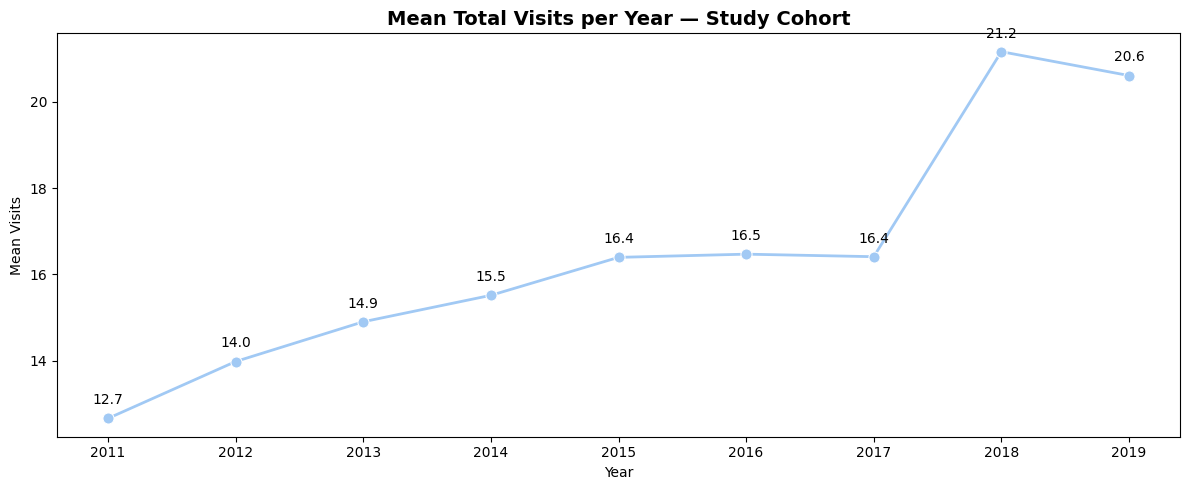

In [7]:
# Get total columns and compute mean per year
total_cols = [col for col in df_9_2011_2019.columns if col.startswith("TOTAL_")]
years = [col.split("_")[1] for col in total_cols]
means = [df_9_2011_2019[col].mean() for col in total_cols]

total_df = pd.DataFrame({"year": years, "mean_visits": means})

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=total_df, x="year", y="mean_visits", marker="o", 
             color=sns.color_palette("pastel")[0], ax=ax, linewidth=2, markersize=8)
ax.set_title("Mean Total Visits per Year — Study Cohort", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Visits")
for i, row in total_df.iterrows():
    ax.annotate(f'{row["mean_visits"]:.1f}', 
                (row["year"], row["mean_visits"]),
                ha='center', va='bottom', xytext=(0, 8), textcoords='offset points')
plt.tight_layout()
plt.savefig("total_visits_per_year.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Check how many patients have non-zero visits per year
for year in years:
    col = f"TOTAL_{year}"
    non_zero = (df_9_2011_2019[col] > 0).sum()
    print(f"{year}: {non_zero} patients with visits, mean={df_9_2011_2019[col].mean():.1f}, mean (non-zero only)={df_9_2011_2019[df_9_2011_2019[col]>0][col].mean():.1f}")

2011: 8266 patients with visits, mean=12.7, mean (non-zero only)=14.6
2012: 8481 patients with visits, mean=14.0, mean (non-zero only)=15.7
2013: 8644 patients with visits, mean=14.9, mean (non-zero only)=16.5
2014: 8761 patients with visits, mean=15.5, mean (non-zero only)=16.9
2015: 8993 patients with visits, mean=16.4, mean (non-zero only)=17.4
2016: 8996 patients with visits, mean=16.5, mean (non-zero only)=17.5
2017: 8990 patients with visits, mean=16.4, mean (non-zero only)=17.4
2018: 8993 patients with visits, mean=21.2, mean (non-zero only)=22.5
2019: 8845 patients with visits, mean=20.6, mean (non-zero only)=22.3


In [18]:
common_vars = ["C01_AP", "C02_AH", "C04_SMP", "C05_SMH", "C06_URG"]

for var in common_vars:
    print(f"\n{var}:")
    for year in years:
        col = f"{var}_{year}"
        if col in df_9_2011_2019.columns:
            print(f"  {year}: mean={df_9_2011_2019[col].mean():.2f}")


C01_AP:
  2011: mean=7.88
  2012: mean=8.40
  2013: mean=8.77
  2014: mean=8.80
  2015: mean=9.32
  2016: mean=9.28
  2017: mean=9.35
  2018: mean=9.17
  2019: mean=8.73

C02_AH:
  2011: mean=0.07
  2012: mean=0.08
  2013: mean=0.09
  2014: mean=0.10
  2015: mean=0.11
  2016: mean=0.13
  2017: mean=0.12
  2018: mean=0.13
  2019: mean=0.13

C04_SMP:
  2011: mean=3.54
  2012: mean=4.29
  2013: mean=4.78
  2014: mean=5.19
  2015: mean=5.50
  2016: mean=5.62
  2017: mean=5.55
  2018: mean=10.37
  2019: mean=10.30

C05_SMH:
  2011: mean=0.23
  2012: mean=0.25
  2013: mean=0.24
  2014: mean=0.28
  2015: mean=0.30
  2016: mean=0.31
  2017: mean=0.25
  2018: mean=0.31
  2019: mean=0.27

C06_URG:
  2011: mean=0.94
  2012: mean=0.96
  2013: mean=1.03
  2014: mean=1.15
  2015: mean=1.16
  2016: mean=1.14
  2017: mean=1.14
  2018: mean=1.18
  2019: mean=1.18


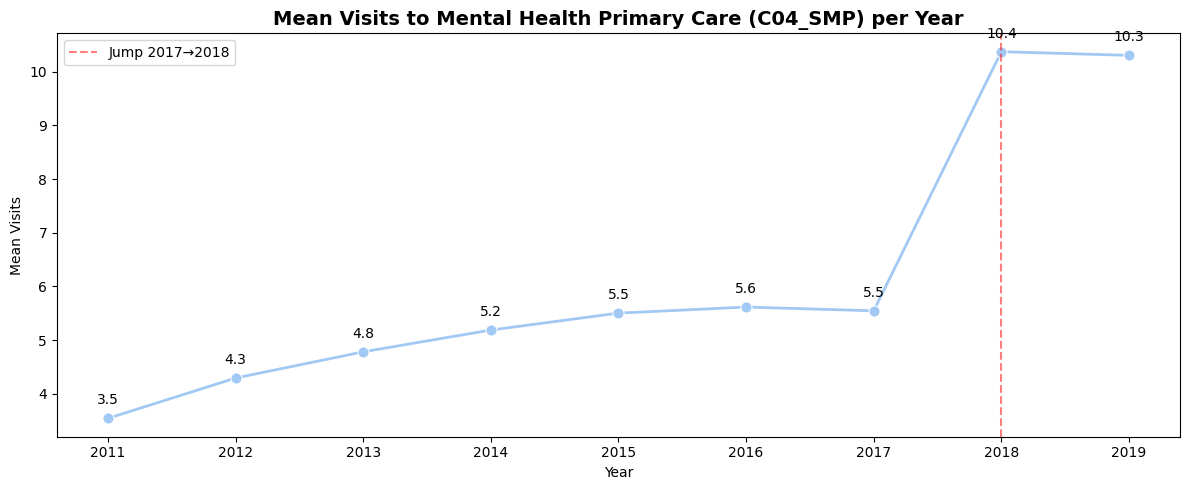

In [19]:
# Salt en el nombre de visites de 2017 a 2018 es degut a C04_SMP, que passa de 0.0 a 0.2 de mitjana, i a més té un percentatge de pacients amb visites que passa de 0% a 20%. Això suggereix que el registre d'aquest tipus de visites va començar a ser capturat o va augmentar significativament a partir de 2018, contribuint al salt en el nombre total de visites.
smp_cols = [f"C04_SMP_{year}" for year in years if f"C04_SMP_{year}" in df_9_2011_2019.columns]
smp_means = [df_9_2011_2019[col].mean() for col in smp_cols]

smp_df = pd.DataFrame({"year": years, "mean_visits": smp_means})

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=smp_df, x="year", y="mean_visits", marker="o",
             color=sns.color_palette("pastel")[0], ax=ax, linewidth=2, markersize=8)
ax.set_title("Mean Visits to Mental Health Primary Care (C04_SMP) per Year", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Visits")
ax.axvline(x="2018", color="red", linestyle="--", alpha=0.5, label="Jump 2017→2018")
ax.legend()
for i, row in smp_df.iterrows():
    ax.annotate(f'{row["mean_visits"]:.1f}',
                (row["year"], row["mean_visits"]),
                ha='center', va='bottom', xytext=(0, 8), textcoords='offset points')
plt.tight_layout()
plt.savefig("smp_visits_per_year.png", dpi=150, bbox_inches="tight")
plt.show()